In [25]:
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator
import csv

from common import make_canvas

In [32]:
d = 10000
dstop = 1000
k = 5
train_size = 100_000
test_size = train_size
train_noise = 0.2
tol = 1e-12
epochs = 300
batch_size = 512

algo_name = "SGD"
lr = 1e-3

plot_every = 20

filename = f'LTH/harm_{algo_name}_d{d}_dstop{dstop}_k{k}_noise{train_noise}_bs{batch_size}_lr{lr}'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

epoch_range = data["epoch"].astype(np.int64)[::plot_every]
train_loss_orig = data["train_loss_orig"].astype(np.float64)[::plot_every]
test_loss_orig = data["test_loss_orig"].astype(np.float64)[::plot_every]
train_loss_cp = data["train_loss_cp"].astype(np.float64)[::plot_every]
test_loss_cp = data["test_loss_cp"].astype(np.float64)[::plot_every]
train_loss_naive = data["train_loss_naive"].astype(np.float64)[::plot_every]
test_loss_naive = data["test_loss_naive"].astype(np.float64)[::plot_every]

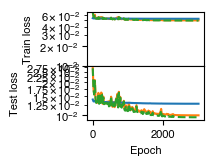

In [ ]:
fig, axs = make_canvas(rows=2, cols=1, axes_width_pt=100, sharex=True, gridspec_kw={'hspace': 0})

axs[0].plot(epoch_range, train_loss_cp, color='tab:orange',marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[0].plot(epoch_range, train_loss_naive, color='tab:blue',  marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[0].plot(epoch_range, train_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[0].set_ylabel('Train loss')
axs[0].set_yticks([0.05, 0.06])
axs[0].set_yscale('log')
# axs[0].legend()

# Plot Test Loss vs. epoch
axs[1].plot(epoch_range, test_loss_cp, color='tab:orange', marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[1].plot(epoch_range, test_loss_naive, color='tab:blue', marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[1].plot(epoch_range, test_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[1].set_ylabel('Test loss')
axs[1].set_xlabel('Epoch')
axs[0].set_yticks([0.01, 0.02])
axs[1].set_yscale('log')

plt.tight_layout()
plt.savefig('out.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()